In [3]:
#importing Files
import pandas as pd
train = pd.read_csv(r'C:\Users\adham\Downloads\walmart-recruiting-store-sales-forecasting\Data\train.csv')
features = pd.read_csv(r'C:\Users\adham\Downloads\walmart-recruiting-store-sales-forecasting\Data\features.csv')
stores = pd.read_csv(r'C:\Users\adham\Downloads\walmart-recruiting-store-sales-forecasting\Data\stores.csv')

print(train.shape)
print(features.shape)
print(stores.shape)

(421570, 5)
(8190, 12)
(45, 3)


In [4]:
display(train.head()) 
display(features.head())
display(stores.head())


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [5]:
# Checking for missing values in the datasets
print(train.isnull().sum())
print(features.isnull().sum())
print(stores.isnull().sum())

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64
Store    0
Type     0
Size     0
dtype: int64


In [6]:
# Convert Date column to datetime
# showing the min and max date in the train dataset
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])
print(train['Date'].min(), train['Date'].max())
print(features['Date'].min(), features['Date'].max())

2010-02-05 00:00:00 2012-10-26 00:00:00
2010-02-05 00:00:00 2013-07-26 00:00:00


In [7]:
# Merging the datasets on Store, Date, and IsHoliday columns
df = train.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
df = df.merge(stores, how='left', on='Store')

print(df.shape)
print(df.columns.tolist())

(421570, 16)
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']


In [8]:
# Fill missing values in markdown columns with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

In [9]:
# Fill missing values in CPI and Unemployment columns with forward fill method
df = df.sort_values(['Store', 'Date'])
df[['CPI', 'Unemployment']] = df.groupby('Store')[['CPI', 'Unemployment']].fillna(method='ffill')

print(df.isnull().sum())

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64


C:\Users\adham\AppData\Local\Temp\ipykernel_17692\3745587550.py:3: FutureWarning: DataFrameGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use DataFrame.fillna instead
  df[['CPI', 'Unemployment']] = df.groupby('Store')[['CPI', 'Unemployment']].fillna(method='ffill')
C:\Users\adham\AppData\Local\Temp\ipykernel_17692\3745587550.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['CPI', 'Unemployment']] = df.groupby('Store')[['CPI', 'Unemployment']].fillna(method='ffill')


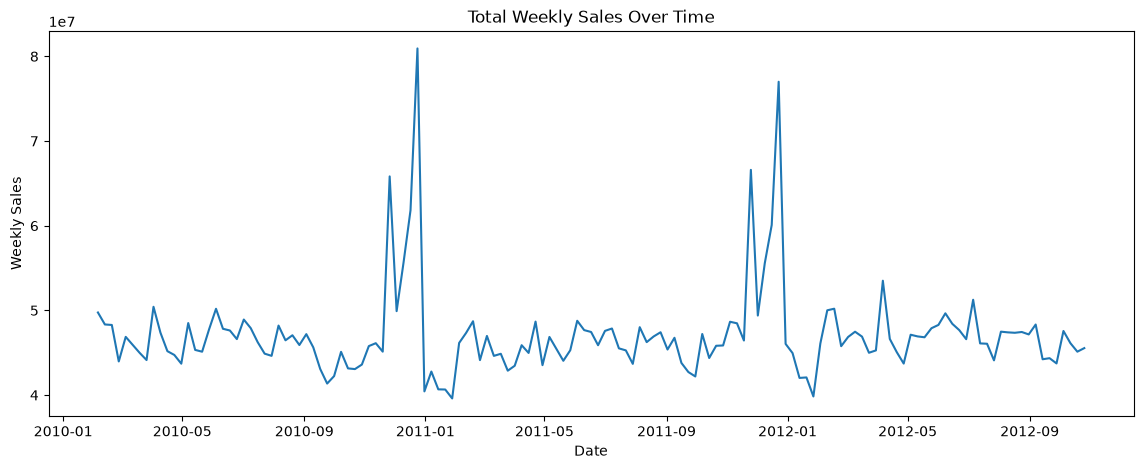

In [10]:
import matplotlib.pyplot as plt
# Plotting the total weekly sales over time
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14,5))
plt.plot(weekly_total.index, weekly_total.values)
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

In [11]:
# Analyzing the average weekly sales during holidays and non-holidays
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].mean()
print(holiday_avg)

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


In [12]:
# Checking for negative sales values
negative_sales = (df['Weekly_Sales'] < 0).sum()
print(f'Negative sales rows: {negative_sales}')

Negative sales rows: 1285


In [13]:
# Showing statistics for rows with negative sales values
print(df[df['Weekly_Sales'] < 0][['Store', 'Dept', 'Date', 'Weekly_Sales']].describe())

             Store         Dept                           Date  Weekly_Sales
count  1285.000000  1285.000000                           1285   1285.000000
mean     23.858366    49.999222  2011-07-03 19:19:50.661478656    -68.608218
min       1.000000     5.000000            2010-02-05 00:00:00  -4988.940000
25%      15.000000    31.000000            2010-11-12 00:00:00    -41.000000
50%      22.000000    47.000000            2011-07-01 00:00:00    -13.200000
75%      35.000000    59.000000            2012-03-16 00:00:00     -4.940000
max      45.000000    99.000000            2012-10-26 00:00:00     -0.020000
std      12.033126    24.394330                            NaN    231.664245


In [14]:
# Handling negative sales values by clipping them to 0
df['Weekly_Sales'] = df['Weekly_Sales'].clip(lower=0)

print((df['Weekly_Sales'] < 0).sum())

0


In [15]:
# Extracting Year, Month, and Week from the Date column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

print(df[['Date', 'Year', 'Month', 'Week']].head())

          Date  Year  Month  Week
0   2010-02-05  2010      2     5
143 2010-02-05  2010      2     5
286 2010-02-05  2010      2     5
429 2010-02-05  2010      2     5
572 2010-02-05  2010      2     5


In [16]:
# Calculating the total weekly sales for each week in the dataset
weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_total = weekly_total.sort_values('Date')

print(weekly_total.shape)
print(weekly_total.head())

(143, 2)
        Date  Weekly_Sales
0 2010-02-05   49750875.98
1 2010-02-12   48336800.10
2 2010-02-19   48277902.33
3 2010-02-26   43970440.65
4 2010-03-05   46872715.16


In [17]:
# Splitting the data into training and testing sets
train_ts = weekly_total.iloc[:-12]
test_ts = weekly_total.iloc[-12:]

print(f'Train: {train_ts.shape}, Test: {test_ts.shape}')

Train: (131, 2), Test: (12, 2)


In [18]:
# Preparing data for Prophet model
from prophet import Prophet

train_prophet = train_ts.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model.fit(train_prophet)

Importing plotly failed. Interactive plots will not work.
13:15:40 - cmdstanpy - INFO - Chain [1] start processing
13:15:42 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
# Making future predictions for the next 12 weeks
future = model.make_future_dataframe(periods=12, freq='W-FRI')
forecast = model.predict(future)

forecast_test = forecast[['ds', 'yhat']].tail(12).reset_index(drop=True)
print(forecast_test)

           ds          yhat
0  2012-08-10  4.671547e+07
1  2012-08-17  4.743680e+07
2  2012-08-24  4.822056e+07
3  2012-08-31  4.800362e+07
4  2012-09-07  4.626379e+07
5  2012-09-14  4.400074e+07
6  2012-09-21  4.297740e+07
7  2012-09-28  4.382651e+07
8  2012-10-05  4.528059e+07
9  2012-10-12  4.564244e+07
10 2012-10-19  4.485117e+07
11 2012-10-26  4.459577e+07


In [20]:
# Comparing actual and predicted sales values
comparison = test_ts.reset_index(drop=True).copy()
comparison['yhat'] = forecast_test['yhat'].values
comparison['error'] = comparison['Weekly_Sales'] - comparison['yhat']

print(comparison)

         Date  Weekly_Sales          yhat         error
0  2012-08-10   47403826.18  4.671547e+07  6.883542e+05
1  2012-08-17   47355393.13  4.743680e+07 -8.140449e+04
2  2012-08-24   47449420.62  4.822056e+07 -7.711367e+05
3  2012-08-31   47159931.47  4.800362e+07 -8.436920e+05
4  2012-09-07   48330449.03  4.626379e+07  2.066656e+06
5  2012-09-14   44226897.92  4.400074e+07  2.261621e+05
6  2012-09-21   44354937.08  4.297740e+07  1.377541e+06
7  2012-09-28   43735713.56  4.382651e+07 -9.079747e+04
8  2012-10-05   47567053.49  4.528059e+07  2.286463e+06
9  2012-10-12   46128909.98  4.564244e+07  4.864681e+05
10 2012-10-19   45122443.96  4.485117e+07  2.712741e+05
11 2012-10-26   45544379.53  4.459577e+07  9.486097e+05


In [21]:
# Calculating evaluation metrics
import numpy as np

mape = np.mean(np.abs(comparison['error']) / comparison['Weekly_Sales']) * 100
wape = np.sum(np.abs(comparison['error'])) / np.sum(comparison['Weekly_Sales']) * 100
bias = np.sum(comparison['error']) / np.sum(comparison['Weekly_Sales']) * 100

print(f'MAPE: {mape:.2f}%')
print(f'WAPE: {wape:.2f}%')
print(f'Bias: {bias:.2f}%')

MAPE: 1.81%
WAPE: 1.83%
Bias: 1.18%


In [22]:
# Analyzing sales by store
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
print(store_sales)

Store
20    3.014014e+08
4     2.995453e+08
14    2.890019e+08
13    2.865180e+08
2     2.753872e+08
10    2.716241e+08
27    2.538572e+08
6     2.237586e+08
1     2.224068e+08
39    2.074465e+08
19    2.066377e+08
31    1.996149e+08
23    1.987527e+08
24    1.940166e+08
11    1.939644e+08
28    1.892715e+08
41    1.813429e+08
32    1.668208e+08
18    1.551158e+08
22    1.470768e+08
12    1.442911e+08
26    1.434166e+08
34    1.382526e+08
40    1.378716e+08
35    1.315300e+08
8     1.299515e+08
17    1.277832e+08
45    1.123973e+08
21    1.081196e+08
25    1.010618e+08
43    9.056653e+07
15    8.913487e+07
7     8.159950e+07
42    7.956804e+07
9     7.779117e+07
29    7.714283e+07
16    7.425674e+07
37    7.420286e+07
30    6.271701e+07
3     5.758793e+07
38    5.515990e+07
36    5.341335e+07
5     4.547612e+07
44    4.329367e+07
33    3.716033e+07
Name: Weekly_Sales, dtype: float64


In [23]:
# Analyzing sales for a specific store
selected_store = 40  
store_df = df[df['Store'] == selected_store]

weekly_store = store_df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_store = weekly_store.sort_values('Date')

print(weekly_store.shape)
print(weekly_store.head())

(143, 2)
        Date  Weekly_Sales
0 2010-02-05    1001943.80
1 2010-02-12     955338.29
2 2010-02-19     916289.20
3 2010-02-26     863941.40
4 2010-03-05     990152.28


In [ ]:
# Splitting the store data into training and testing sets
train_store = weekly_store.iloc[:-12]
test_store = weekly_store.iloc[-12:]

print(f'Train: {train_store.shape}, Test: {test_store.shape}')

Train: (131, 2), Test: (12, 2)


In [ ]:
# Preparing data for Prophet model for the selected store
train_store_prophet = train_store.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

model_store = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model_store.fit(train_store_prophet)

13:15:42 - cmdstanpy - INFO - Chain [1] start processing
13:15:42 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# Making future predictions for the next 12 weeks for the selected store
future_store = model_store.make_future_dataframe(periods=12, freq='W-FRI')
forecast_store = model_store.predict(future_store)

forecast_store_test = forecast_store[['ds', 'yhat']].tail(12).reset_index(drop=True)
print(forecast_store_test)

           ds           yhat
0  2012-08-10  987613.786514
1  2012-08-17  991333.796452
2  2012-08-24  999364.284361
3  2012-08-31  992913.663222
4  2012-09-07  962263.555662
5  2012-09-14  925961.236451
6  2012-09-21  915978.369033
7  2012-09-28  940939.447449
8  2012-10-05  972751.450710
9  2012-10-12  977681.258450
10 2012-10-19  956687.224804
11 2012-10-26  944119.767702


In [ ]:
# Comparing actual and predicted sales values for the selected store
comparison_store = test_store.reset_index(drop=True).copy()
comparison_store['yhat'] = forecast_store_test['yhat'].values
comparison_store['error'] = comparison_store['Weekly_Sales'] - comparison_store['yhat']

print(comparison_store)

mape_store = np.mean(np.abs(comparison_store['error']) / comparison_store['Weekly_Sales']) * 100
wape_store = np.sum(np.abs(comparison_store['error'])) / np.sum(comparison_store['Weekly_Sales']) * 100
bias_store = np.sum(comparison_store['error']) / np.sum(comparison_store['Weekly_Sales']) * 100

print(f'MAPE (Store 40): {mape_store:.2f}%')
print(f'WAPE (Store 40): {wape_store:.2f}%')
print(f'Bias (Store 40): {bias_store:.2f}%')


         Date  Weekly_Sales           yhat          error
0  2012-08-10    1007906.43  987613.786514   20292.643486
1  2012-08-17     969387.48  991333.796452  -21946.316452
2  2012-08-24     945318.47  999364.284361  -54045.814361
3  2012-08-31     987264.67  992913.663222   -5648.993222
4  2012-09-07    1088248.40  962263.555662  125984.844338
5  2012-09-14     901709.82  925961.236451  -24251.416451
6  2012-09-21     899803.38  915978.369033  -16174.989033
7  2012-09-28     919595.44  940939.447449  -21344.007449
8  2012-10-05    1069112.00  972751.450710   96360.549290
9  2012-10-12     982523.26  977681.258450    4842.001550
10 2012-10-19     918170.50  956687.224804  -38516.724804
11 2012-10-26     921264.52  944119.767702  -22855.247702
MAPE (Store 40): 3.76%
WAPE (Store 40): 3.90%
Bias (Store 40): 0.37%


In [30]:
# 1. البيانات الأساسية الكاملة (بعد التنظيف) — لعمل تحليلات عامة
df.to_csv('C:\\Users\\adham\\Downloads\\walmart-recruiting-store-sales-forecasting\\Outputs\\cleaned_sales_data.csv', index=False)

# 2. مقارنة الفعلي بالتوقع - المستوى الكلي
comparison.to_csv('C:\\Users\\adham\\Downloads\\walmart-recruiting-store-sales-forecasting\\Outputs\\forecast_comparison_total.csv', index=False)

# 3. مقارنة الفعلي بالتوقع - متجر 40
comparison_store.to_csv('C:\\Users\\adham\\Downloads\\walmart-recruiting-store-sales-forecasting\\Outputs\\forecast_comparison_store40.csv', index=False)

print('تم التصدير بنجاح')

تم التصدير بنجاح
